In [ ]:
# ============================================
# CELL 1 — INSTALL LIBRARIES
# ============================================

!pip install xgboost opencv-python kagglehub -q

In [ ]:
# ============================================
# CELL 2 — IMPORT LIBRARIES
# ============================================

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

os.makedirs("outputs", exist_ok=True)

In [ ]:
# ============================================
# CELL 3 — DOWNLOAD DATASET
# ============================================

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset Path :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path : /kaggle/input/chest-xray-pneumonia


In [ ]:
# ============================================
# CELL 4 — DEFINE CLASSES
# ============================================

classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

dec = {
    0: 'Normal',
    1: 'Pneumonia'
}

IMG_SIZE = 128

In [ ]:
# ============================================
# CELL 5 — LOAD RAW PIXEL DATASET
# ============================================

train_path = os.path.join(
    path,
    "chest_xray",
    "train"
)

X = []
Y = []

print("Loading Images...\n")

for cls, label in classes.items():

    class_path = os.path.join(
        train_path,
        cls
    )

    count = 0

    for filename in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            filename
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None:

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            # RAW PIXELS → NO PCA
            img = img.flatten() / 255.0

            X.append(img)

            Y.append(label)

            count += 1

    print(f"{cls} : {count} images loaded")

X = np.array(
    X,
    dtype=np.float32
)

Y = np.array(Y)

print("\nDataset Loaded Successfully")

print("X Shape :", X.shape)

print("Y Shape :", Y.shape)

print("\nNORMAL     :", np.sum(Y==0))

print("PNEUMONIA :", np.sum(Y==1))

Loading Images...

NORMAL : 1341 images loaded
PNEUMONIA : 3875 images loaded

Dataset Loaded Successfully
X Shape : (5216, 16384)
Y Shape : (5216,)

NORMAL     : 1341
PNEUMONIA : 3875


In [ ]:
# ============================================
# CELL 6 — DATA SPLITS
# ============================================

splits = [
    (0.2, 0.8),
    (0.4, 0.6),
    (0.6, 0.4),
    (0.8, 0.2)
]


TRAIN : 20%
TEST  : 80%
Training Samples : 1043
Testing Samples  : 4173

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.9532710280373832
F1 Score          : 0.9529846091656523
Sensitivity       : 0.9748387096774194
Specificity       : 0.8909599254426841

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.89      0.91      1073
   Pneumonia       0.96      0.97      0.97      3100

    accuracy                           0.95      4173
   macro avg       0.94      0.93      0.94      4173
weighted avg       0.95      0.95      0.95      4173



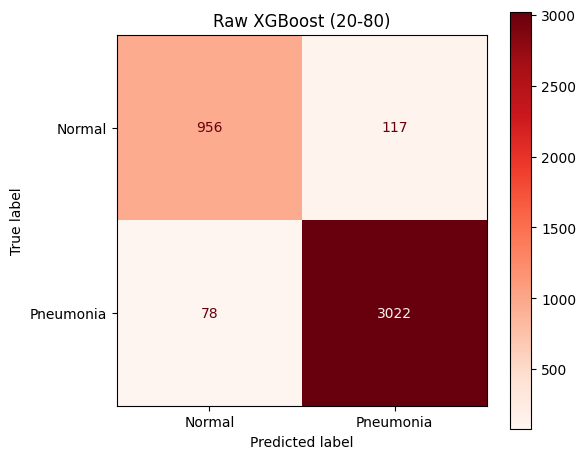


TRAIN : 40%
TEST  : 60%
Training Samples : 2086
Testing Samples  : 3130

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.9559105431309904
F1 Score          : 0.9558200698624689
Sensitivity       : 0.9724731182795698
Specificity       : 0.9080745341614906

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.91      0.91       805
   Pneumonia       0.97      0.97      0.97      2325

    accuracy                           0.96      3130
   macro avg       0.94      0.94      0.94      3130
weighted avg       0.96      0.96      0.96      3130



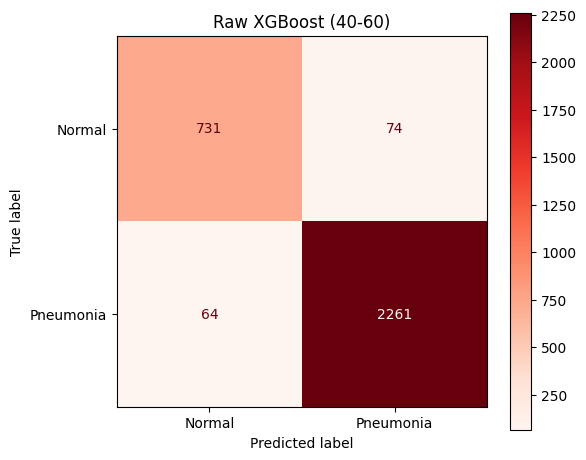


TRAIN : 60%
TEST  : 40%
Training Samples : 3129
Testing Samples  : 2087

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.9626257786296119
F1 Score          : 0.9626933571703717
Sensitivity       : 0.9729032258064516
Specificity       : 0.9329608938547486

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.93      0.93       537
   Pneumonia       0.98      0.97      0.97      1550

    accuracy                           0.96      2087
   macro avg       0.95      0.95      0.95      2087
weighted avg       0.96      0.96      0.96      2087



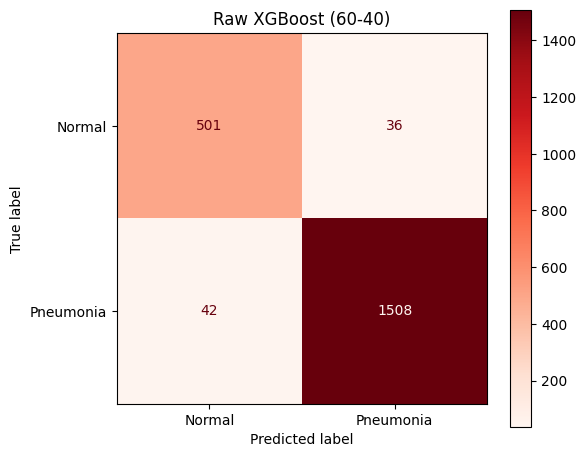


TRAIN : 80%
TEST  : 20%
Training Samples : 4172
Testing Samples  : 1044

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.9616858237547893
F1 Score          : 0.9616387295581406
Sensitivity       : 0.9755154639175257
Specificity       : 0.9216417910447762

Classification Report:

              precision    recall  f1-score   support

      Normal       0.93      0.92      0.93       268
   Pneumonia       0.97      0.98      0.97       776

    accuracy                           0.96      1044
   macro avg       0.95      0.95      0.95      1044
weighted avg       0.96      0.96      0.96      1044



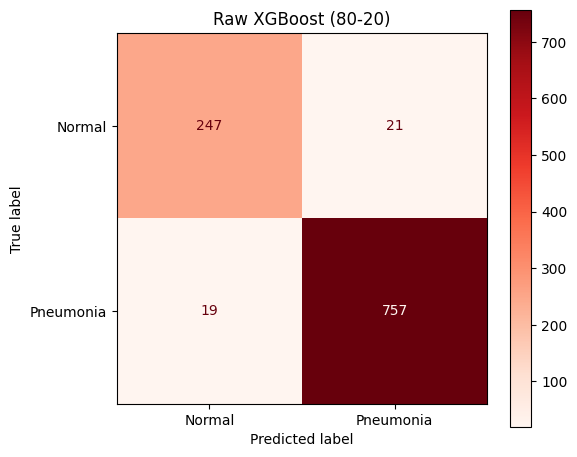

In [ ]:
# ============================================
# CELL 7 — RAW XGBOOST TRAINING
# ============================================

train_acc_list = []

test_acc_list = []

f1_list = []

sensitivity_list = []

specificity_list = []

labels = []

for train_ratio, test_ratio in splits:

    print("\n======================================")

    print(f"TRAIN : {int(train_ratio*100)}%")

    print(f"TEST  : {int(test_ratio*100)}%")

    print("======================================")

    # TRAIN TEST SPLIT
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_ratio,
        test_size=test_ratio,
        random_state=42,
        stratify=Y
    )

    print("Training Samples :", xtrain.shape[0])

    print("Testing Samples  :", xtest.shape[0])

    # XGBOOST MODEL
    xgb = XGBClassifier(

        n_estimators=150,

        max_depth=5,

        learning_rate=0.1,

        subsample=0.8,

        colsample_bytree=0.3,

        # Pneumonia is majority class.
        # Reduce majority-class dominance.

        scale_pos_weight=np.sum(Y==0)/np.sum(Y==1),

        tree_method='hist',

        eval_metric='logloss',

        random_state=42,

        n_jobs=-1,

        verbosity=0
    )

    print("\nTraining Raw XGBoost Model...")

    xgb.fit(
        xtrain,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(
        xtrain
    )

    test_pred = xgb.predict(
        xtest
    )

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        ytest,
        test_pred
    )

    f1 = f1_score(
        ytest,
        test_pred,
        average='weighted'
    )

    cm = confusion_matrix(
        ytest,
        test_pred
    )

    sensitivity = (
        cm[1,1] /
        (cm[1,1] + cm[1,0])
    )

    specificity = (
        cm[0,0] /
        (cm[0,0] + cm[0,1])
    )

    print("Training Accuracy :", train_acc)

    print("Testing Accuracy  :", test_acc)

    print("F1 Score          :", f1)

    print("Sensitivity       :", sensitivity)

    print("Specificity       :", specificity)

    # STORE RESULTS
    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    sensitivity_list.append(sensitivity)

    specificity_list.append(specificity)

    labels.append(
        f"{int(train_ratio*100)}-{int(test_ratio*100)}"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            ytest,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Reds',
        colorbar=True
    )

    plt.title(
        f"Raw XGBoost ({int(train_ratio*100)}-{int(test_ratio*100)})"
    )

    plt.tight_layout()

    plt.show()

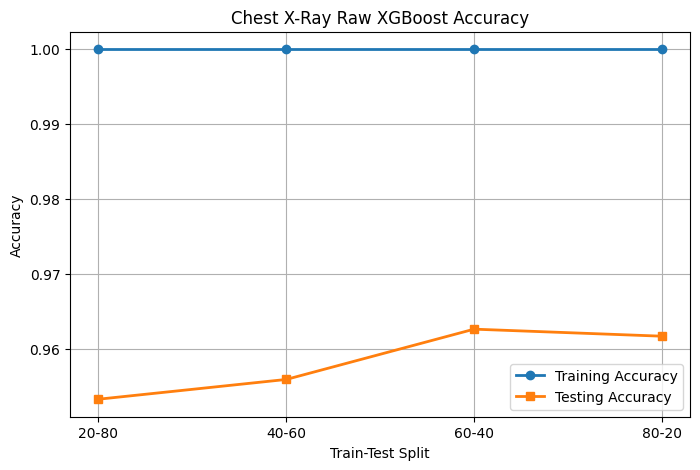

In [ ]:
# ============================================
# CELL 8 — ACCURACY PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Accuracy")

plt.title("Chest X-Ray Raw XGBoost Accuracy")

plt.legend()

plt.grid(True)

plt.show()

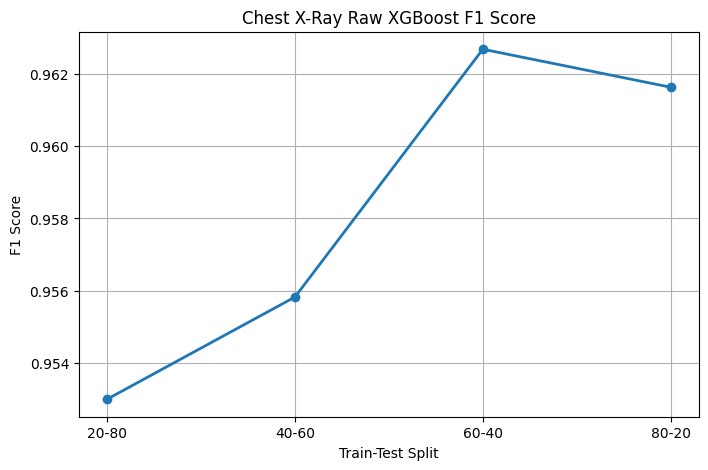

In [ ]:
# ============================================
# CELL 9 — F1 SCORE PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("Chest X-Ray Raw XGBoost F1 Score")

plt.grid(True)

plt.show()

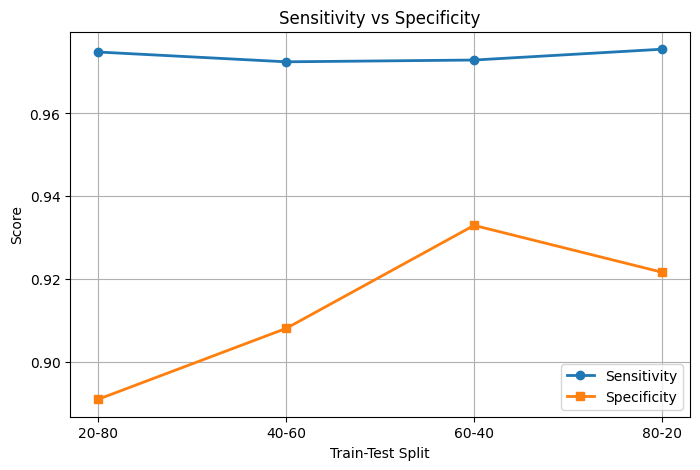

In [ ]:
# ============================================
# CELL 10 — SENSITIVITY & SPECIFICITY
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    sensitivity_list,
    marker='o',
    linewidth=2,
    label='Sensitivity'
)

plt.plot(
    labels,
    specificity_list,
    marker='s',
    linewidth=2,
    label='Specificity'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Score")

plt.title("Sensitivity vs Specificity")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# CELL 11 — RESULTS TABLE
# ============================================

results_df = pd.DataFrame({

    'Train-Test Split': labels,

    'Training Accuracy': train_acc_list,

    'Testing Accuracy': test_acc_list,

    'F1 Score': f1_list,

    'Sensitivity': sensitivity_list,

    'Specificity': specificity_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score  \
0            20-80                1.0          0.953271  0.952985   
1            40-60                1.0          0.955911  0.955820   
2            60-40                1.0          0.962626  0.962693   
3            80-20                1.0          0.961686  0.961639   

   Sensitivity  Specificity  
0     0.974839     0.890960  
1     0.972473     0.908075  
2     0.972903     0.932961  
3     0.975515     0.921642  


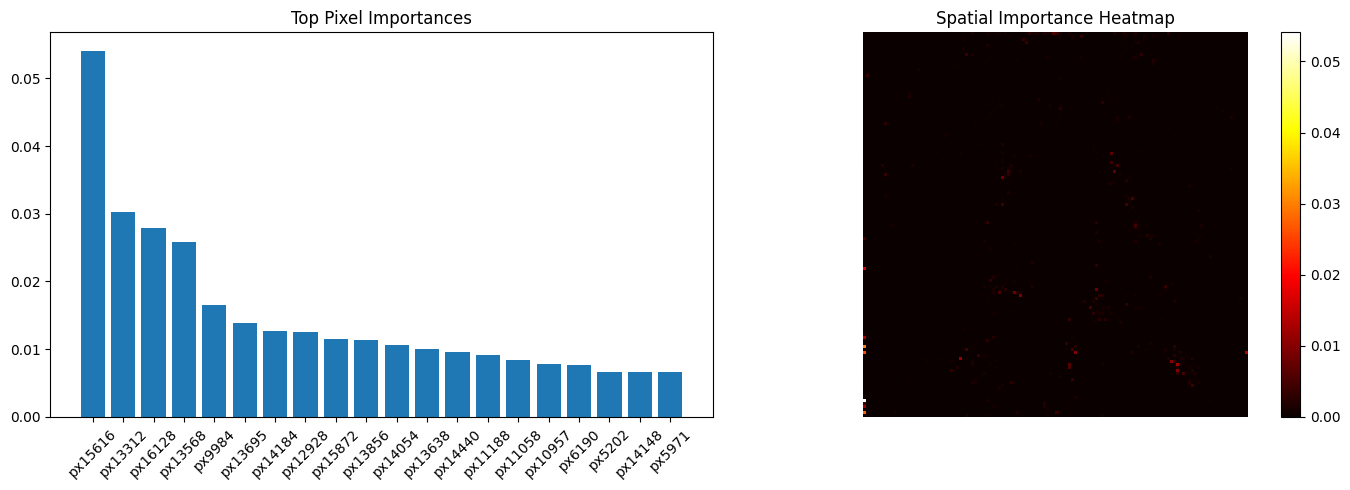

In [ ]:
# ============================================
# CELL 12 — FEATURE IMPORTANCE
# ============================================

importances = xgb.feature_importances_

importance_map = importances.reshape(
    IMG_SIZE,
    IMG_SIZE
)

top_idx = np.argsort(
    importances
)[::-1][:20]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# TOP FEATURES
axes[0].bar(
    range(20),
    importances[top_idx]
)

axes[0].set_xticks(range(20))

axes[0].set_xticklabels(
    [f"px{idx}" for idx in top_idx],
    rotation=45
)

axes[0].set_title(
    "Top Pixel Importances"
)

# HEATMAP
im = axes[1].imshow(
    importance_map,
    cmap='hot'
)

axes[1].set_title(
    "Spatial Importance Heatmap"
)

axes[1].axis('off')

plt.colorbar(im)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# CELL 13 — SAMPLE PREDICTIONS
# ============================================

test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)

def display_samples(folder, title, num_samples=9):

    valid_ext = (
        '.jpg',
        '.jpeg',
        '.png'
    )

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    if len(imgs) == 0:
        return

    cols = min(3, len(imgs))

    rows = (len(imgs) + cols - 1) // cols

    plt.figure(figsize=(12,4*rows))

    for i, filename in enumerate(imgs, 1):

        img_path = os.path.join(
            folder,
            filename
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        pred = xgb.predict(
            [img.flatten()/255.0]
        )[0]

        plt.subplot(rows, cols, i)

        plt.imshow(
            img,
            cmap='gray'
        )

        plt.title(
            dec[pred],
            color='green' if pred == 0 else 'red'
        )

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

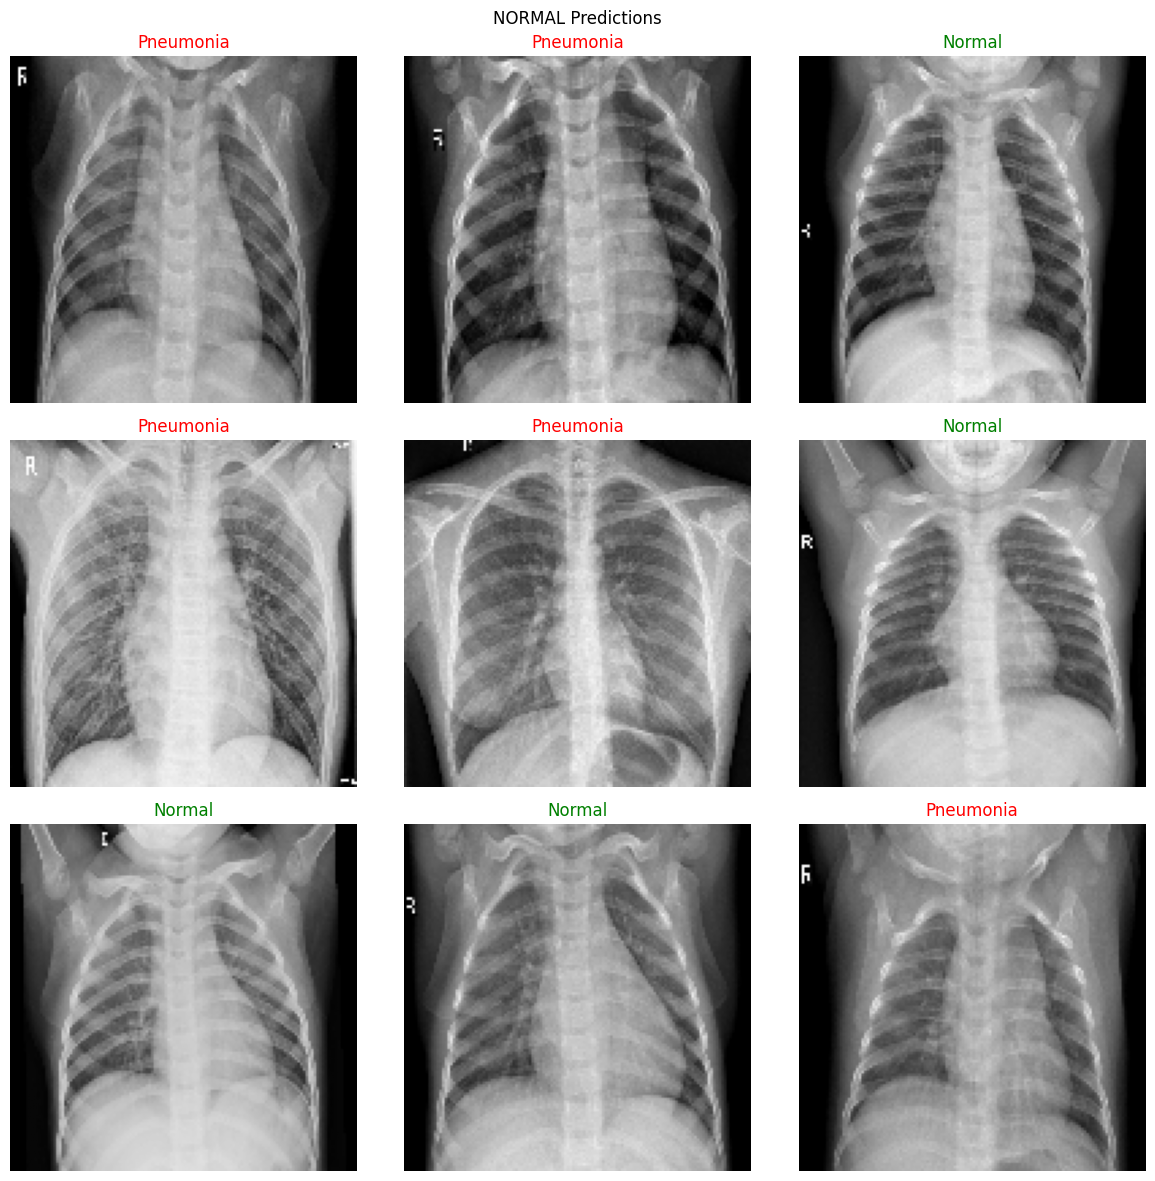

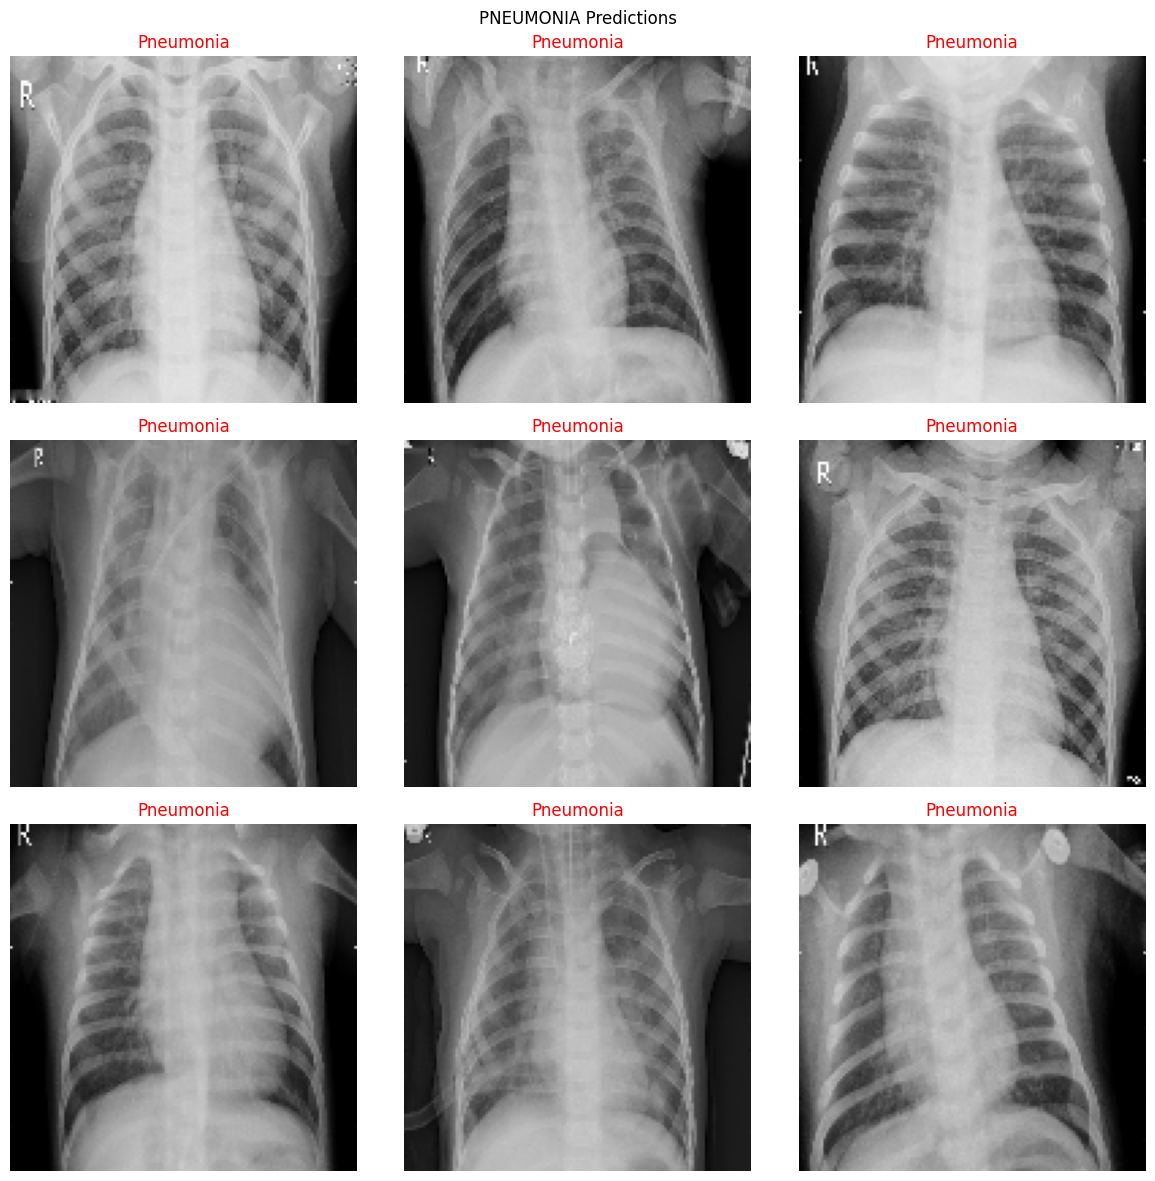

In [ ]:
# ============================================
# CELL 14 — DISPLAY SAMPLE PREDICTIONS
# ============================================

for cls_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        cls_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            f"{cls_folder} Predictions"
        )

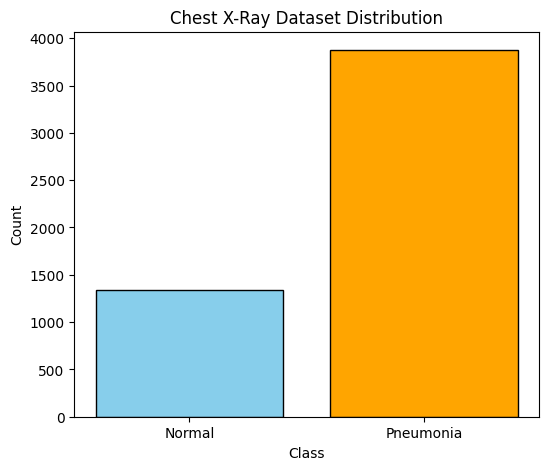

In [ ]:
# ============================================
# CELL 15 — DATASET DISTRIBUTION
# ============================================

plt.figure(figsize=(6,5))

for label, color in zip(
    [0,1],
    ['skyblue', 'orange']
):

    plt.bar(
        dec[label],
        int(np.sum(Y == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Class")

plt.ylabel("Count")

plt.title("Chest X-Ray Dataset Distribution")

plt.show()